In [1]:
using LinearAlgebra
using Distributed

println("hostname = ", readchomp(`hostname`))
println("threads = ", Threads.nthreads())
println("workers = ", nworkers())
println("BLAS threads = ", BLAS.get_num_threads())

hostname = wifi-secure4-376.sri.ucl.ac.be
threads = 1
workers = 1
BLAS threads = 4


In [2]:
using Eliashberg
using CairoMakie

## 1D Tight-Binding model 

In [4]:
lattice= ChainLattice(1.5) # 晶格常数 1.5 的一维链
kgrid = generate_reciprocal_lattice(lattice, 2000)

tb = TightBinding(lattice, 1.0, -0.3)

TightBinding{1}(ChainLattice(1.5, [1.5;;]), Tuple{StaticArraysCore.SVector{1, Int64}, Float64}[([1], -1.0)], -0.3)

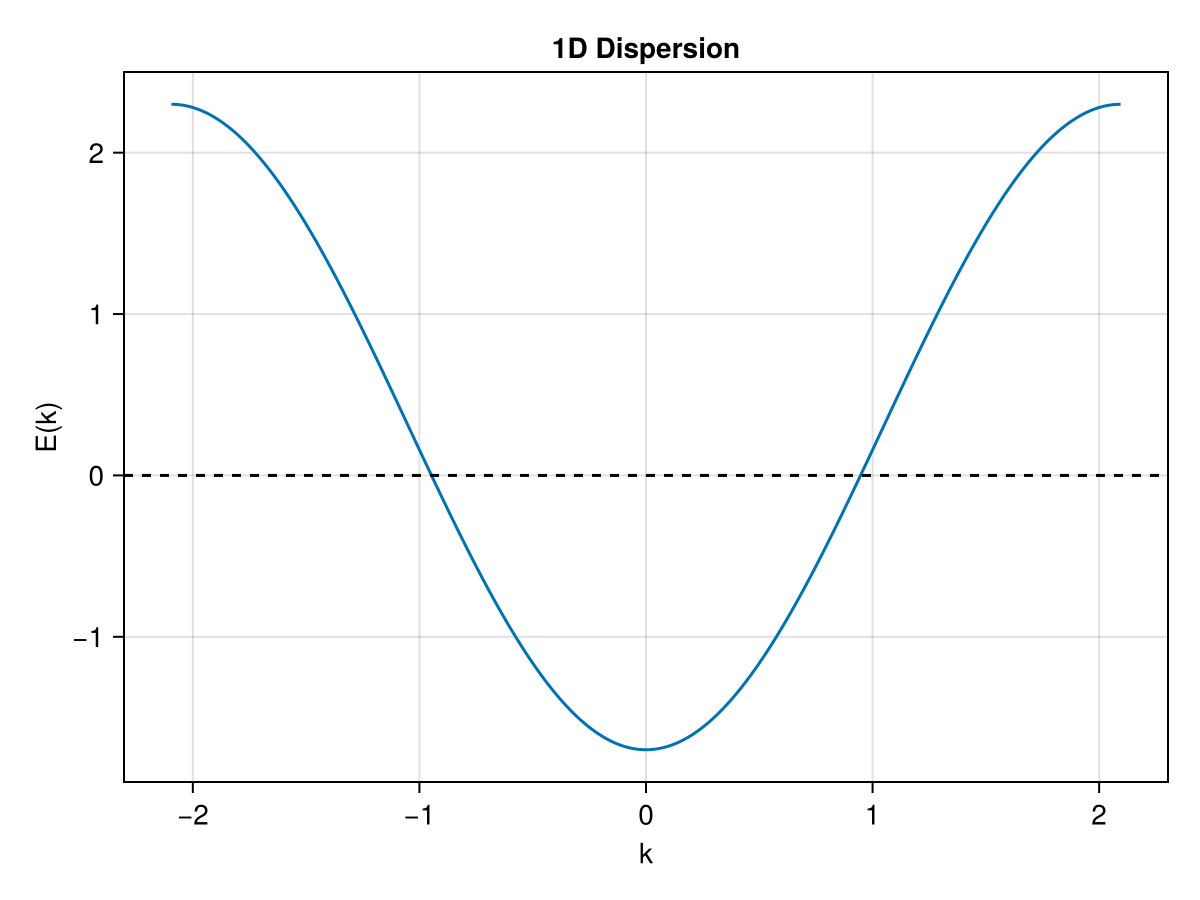

In [6]:
band_data = compute_band_data(tb, generate_kpath(lattice; n_pts_per_segment=100))
f = plot(band_data)
save("tb_1d_eband.png", f)
f


### BCS reduced Hamiltonian


In [7]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-2.5)

sc_field = BCSReducedPairing(:s_wave)

phis = range(0.0, 1.0, length=100)  # 序参量扫描范围
Ts = range(0.1, 0.4, length=10)     # 温度扫描范围 (从极低温到超过 Tc)

kpath = generate_kpath(lattice; n_pts_per_segment=50)


KPath{1}(StaticArraysCore.SVector{1, Float64}[[0.0], [0.041887902047863905], [0.08377580409572781], [0.1256637061435917], [0.16755160819145562], [0.20943951023931953], [0.2513274122871834], [0.2932153143350474], [0.33510321638291124], [0.37699111843077515]  …  [1.71740398396242], [1.759291886010284], [1.801179788058148], [1.843067690106012], [1.8849555921538759], [1.9268434942017396], [1.9687313962496034], [2.0106192982974673], [2.0525072003453313], [2.0943951023931953]], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], [1, 51], ["Γ", "X"])

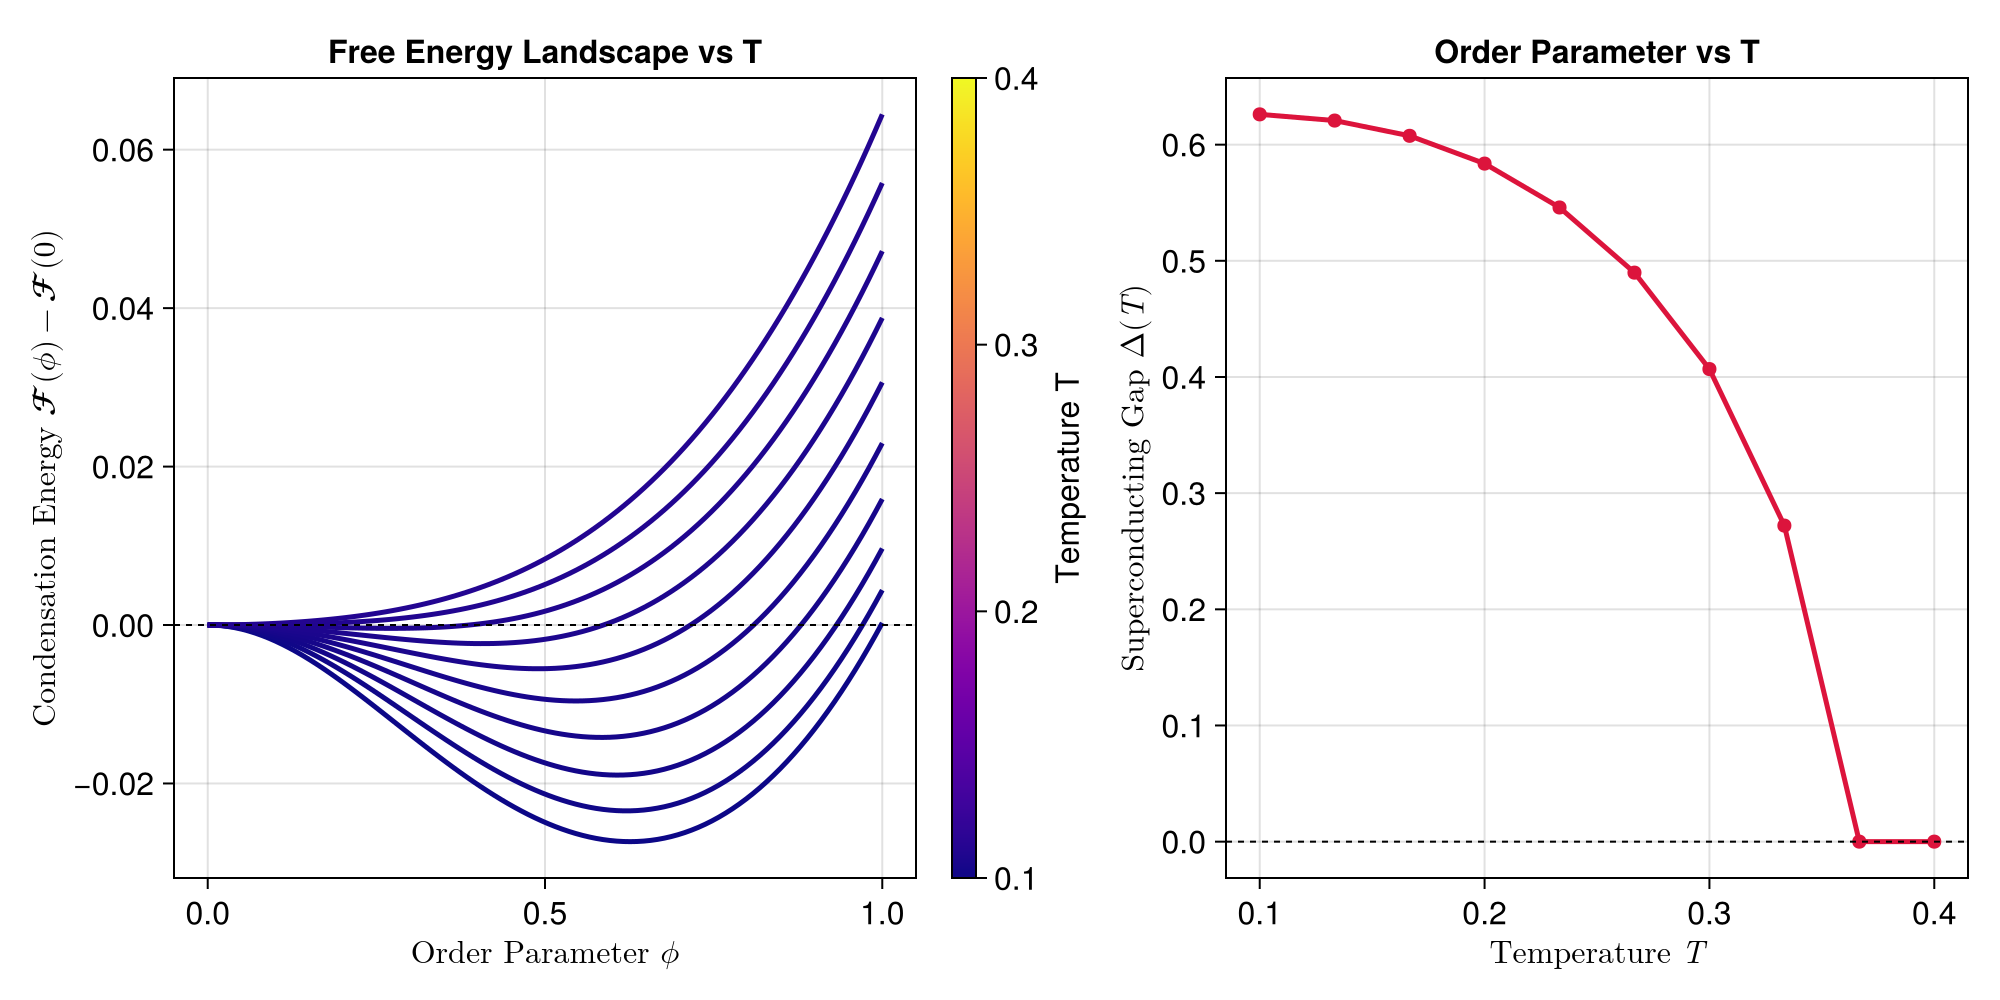

In [8]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


In [ ]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, kpath)
plot(band_data)


In [ ]:
T_val = 0.1
collective_data = compute_collective_mode_spectral_data(T_val, sc_field, tb, interaction, kgrid, kpath; eta=0.015)
plot(collective_data)


### FFLO Pairing

In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-2.5)

# 设定环境参数
T_val = 0.01
h_val = 0.5 # 施加一个 Zeeman 磁场 (注意：h 必须小于裸能隙，但在 Pauli 极限附近)

# 2. 设定我们要扫描的 q 范围 (沿着 qx 方向)
q_vals = range(0.0, 1.0, length=300) # 扫描 0 到 1.0 的动量

zeeman_data = compute_zeeman_pairing_data(T_val, h_val, q_vals, tb, interaction, kgrid)
plot_zeeman_pairing_landscape(q_vals, zeeman_data.condensation_energy, zeeman_data.optimal_gaps; minimum_index=zeeman_data.minimum_index)

## 2D Tight-Binding model


### BCS reduced Hamiltonian

In [ ]:

lattice = SquareLattice(1.5)
tb = TightBinding(lattice, 1.0, 0.0)

kgrid = generate_reciprocal_lattice(lattice, 50, 50)

path = generate_kpath(lattice; n_pts_per_segment=50)

In [ ]:
band_data = compute_band_data(tb, path)
plot(band_data)


In [ ]:
dispersion_data = compute_dispersion_surface_data(tb, kgrid)
f = plot_dispersion_surface(dispersion_data.kxs, dispersion_data.kys, dispersion_data.energy_matrix)
save("tb_2d_eband.png", f)
f


#### s-wave

In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-2.5)

sc_field = BCSReducedPairing(:s_wave)

phis = range(0.0, 1.0, length=100)  # 序参量扫描范围
Ts = range(0.1, 0.4, length=10)   # 温度扫描范围 (从极低温到超过 Tc)



In [ ]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


In [ ]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, path)
plot(band_data)


#### $s_{\pm}$ wave

In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-5)

sc_field = BCSReducedPairing(:s_plus_minus_wave)

phis = range(0.0, 1.0, length=100)  # 序参量扫描范围
Ts = range(0.1, 0.4, length=10)   # 温度扫描范围 (从极低温到超过 Tc)

In [ ]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


In [ ]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, path)
plot(band_data)


#### p-wave

In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-2.5)

sc_field = BCSReducedPairing(:p_wave)

phis = range(0.0, 1.0, length=100)  # 序参量扫描范围
Ts = range(0.1, 0.5, length=10)   # 温度扫描范围 (从极低温到超过 Tc)


In [ ]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


In [ ]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, path)
plot(band_data)


#### d-wave

In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-3.5)

sc_field = BCSReducedPairing(:d_wave)

phis = range(0.0, 1.0, length=100)  # 序参量扫描范围
Ts = range(0.1, 0.5, length=10)   # 温度扫描范围 (从极低温到超过 Tc)

In [ ]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


In [ ]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, path)
plot(band_data)


## 3D Tight-Binding model

In [ ]:
lattice = CubicLattice(1.5)
tb = TightBinding(lattice, 1.0, 0.0)

kgrid = generate_reciprocal_lattice(lattice, 20, 20, 20)

path = generate_kpath(lattice; n_pts_per_segment=20)



In [ ]:
band_data = compute_band_data(tb, path)
f = plot(band_data)
save("tb_3d_eband_GXMGR.png", f)
f


In [ ]:
# fermi_surface = compute_fermi_surface_volume(tb; n_pts=60)
# f = plot_fermi_surface(fermi_surface.kxs, fermi_surface.kys, fermi_surface.kzs, fermi_surface.energy_volume; E_Fermi=0.0)
# save("tb_3d_eband_fs.png", f)


In [ ]:
# 定义引力相互作用 (超导是由有效吸引力驱动的，我们设 V < 0)
interaction = ConstantInteraction(-2.5)

sc_field = BCSReducedPairing(:s_wave)

phis = range(0.0, 1.0, length=100)  # 序参量扫描范围
Ts = range(0.1, 0.4, length=10)   # 温度扫描范围 (从极低温到超过 Tc)


In [ ]:
phase_data = compute_phase_transition_data(phis, Ts, sc_field, tb, interaction, kgrid)
plot(phase_data)


In [ ]:
band_data = compute_renormalized_band_data(Ts, sc_field, tb, interaction, kgrid, path)
plot(band_data)
